In [1]:
import os
import json
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
import numpy as np
import pandas as pd

def read_json(path):
    with open(path, 'r', encoding="utf-8") as f:
        data = json.load(f)
    return data

def write_json(data, path):
    if not os.path.exists(os.path.dirname(path)):
        os.makedirs(os.path.dirname(path))
    with open(path, 'w', encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)

In [2]:


def forgetting_rate(accuracy_matrix):
    """
    Computes forgetting for each task.
    
    Parameters:
    - accuracy_matrix: 2D numpy array of shape (num_tasks, num_tasks)
      Each row i represents accuracy on task i after training on tasks j=0..T-1
    
    Returns:
    - forgetting: list of forgetting values for each task
    - avg_forgetting: average forgetting across tasks (excluding the last task)
    """
    num_tasks = accuracy_matrix.shape[0]
    forgetting = []

    for i in range(num_tasks - 1):
        max_acc = np.max(accuracy_matrix[i, :i+1])  # Max accuracy before final training
        final_acc = accuracy_matrix[i, -1]          # Accuracy after training on all tasks
        forgetting.append(max_acc - final_acc)

    avg_forgetting = np.mean(forgetting)
    return forgetting, avg_forgetting


In [3]:
# matrices preparation on T5
def compute_forgetting_matrix_t5(input_folder, test_folder):
    results = []
    for i in range(1, 9):
       input_file = f"/Users/sefika/phd_projects/llm-catastrophic-re/last_results/tacred/tacred_oja/{input_folder}/test_pred_{i}.json"
       start=0 
       predictions = read_json(input_file)
       predictions = [item['predict'] for item in predictions]
       
       for id in range(1, i+1):
        test_file = f"/Users/sefika/phd_projects/draft/FS-CRE/data/data/tacred/5way5shot_same_setting_kmeans/5way5shot-test/{test_folder}/task{id}/test.json"
        test_data = read_json(test_file)
        y_true = [item['relation'] for item in test_data]
        y_task = predictions[start:start+len(y_true)]
        acc = accuracy_score(y_true, y_task)*100
        print(f"Task {i} - Task {id} Accuracy: {acc:.4f}")
        print(f"Task {i} - Task {id} Size: {len(y_task)}")
        print(f"Task {i} - Task {id} True Size: {len(y_true)}")

        row = {'base_task':i , 'task':id, 'accuracy':acc}
        
        start += len(y_true)
        results.append(row)
    return results
for run_id in range(1, 6):
    results = compute_forgetting_matrix_t5(
        input_folder=f"model_{run_id}",
        test_folder=f"run{run_id}"
    )
    results
    write_json(results, f"/Users/sefika/phd_projects/llm-catastrophic-re/last_results/tacred/tacred_oja/model_{run_id}_forgetting_matrix.json")


Task 1 - Task 1 Accuracy: 98.1818
Task 1 - Task 1 Size: 770
Task 1 - Task 1 True Size: 770
Task 2 - Task 1 Accuracy: 97.1429
Task 2 - Task 1 Size: 770
Task 2 - Task 1 True Size: 770
Task 2 - Task 2 Accuracy: 98.8156
Task 2 - Task 2 Size: 591
Task 2 - Task 2 True Size: 591
Task 3 - Task 1 Accuracy: 97.6623
Task 3 - Task 1 Size: 770
Task 3 - Task 1 True Size: 770
Task 3 - Task 2 Accuracy: 98.6464
Task 3 - Task 2 Size: 591
Task 3 - Task 2 True Size: 591
Task 3 - Task 3 Accuracy: 99.7191
Task 3 - Task 3 Size: 356
Task 3 - Task 3 True Size: 356
Task 4 - Task 1 Accuracy: 97.1429
Task 4 - Task 1 Size: 770
Task 4 - Task 1 True Size: 770
Task 4 - Task 2 Accuracy: 98.4772
Task 4 - Task 2 Size: 591
Task 4 - Task 2 True Size: 591
Task 4 - Task 3 Accuracy: 99.4382
Task 4 - Task 3 Size: 356
Task 4 - Task 3 True Size: 356
Task 4 - Task 4 Accuracy: 97.2881
Task 4 - Task 4 Size: 295
Task 4 - Task 4 True Size: 295
Task 5 - Task 1 Accuracy: 96.7532
Task 5 - Task 1 Size: 770
Task 5 - Task 1 True Size: 770

In [26]:
def make_matrices(accuracy_matrix):
    """
    Prepares the accuracy matrix for forgetting rate computation.
    
    Parameters:
    - accuracy_matrix: 2D numpy array of shape (num_tasks, num_tasks)
      Each row i represents accuracy on task i after training on tasks j=0..T-1
    
    Returns:
    - prepared_matrix: 2D numpy array of shape (num_tasks, num_tasks)
      The prepared matrix for forgetting rate computation
    """
    # Pivot the accuracy matrix
    prepared_matrix = accuracy_matrix.pivot(index='base_task', columns='task', values='accuracy').fillna(0).values
    return prepared_matrix.T


In [27]:
# Forgetting rate for baseline models
forgetting_rates, avg_forgetting_list = [], []
for run_id in range(1, 6):
    acc_path = f"/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/baseline/model_{run_id}_forgetting_matrix.json"
    accuracy_matrix = pd.read_json(acc_path)
    accuracy_matrix = make_matrices(accuracy_matrix)
    forgetting, avg_forgetting = forgetting_rate(accuracy_matrix)
    # print(accuracy_matrix)
    print(f"Run {run_id} - Forgetting: {forgetting}")
    print(f"Run {run_id} - Average Forgetting: {avg_forgetting}")
    row = {'run_id': run_id, 'forgetting': forgetting, 'avg_forgetting': avg_forgetting}
    forgetting_rates.append(row)
    avg_forgetting_list.append(avg_forgetting)
print("Average Forgetting across runs:", np.mean(avg_forgetting_list))
print("Std Average Rates across runs:", np.std(avg_forgetting_list))
write_json(forgetting_rates, f"/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/baseline/forgetting_rates.json")

Run 1 - Forgetting: [0.027857142857143025, 0.04500000000000004, 0.017142857142857015, 0.05428571428571405, 0.016428571428571015, 0.06785714285714295, 0.005714285714286005]
Run 1 - Average Forgetting: 0.03346938775510201
Run 2 - Forgetting: [0.0050000000000000044, 0.03285714285714303, 0.03571428571428503, 0.04857142857142793, 0.040000000000000036, 0.08857142857142908, 0.0050000000000000044]
Run 2 - Average Forgetting: 0.03653061224489788
Run 3 - Forgetting: [0.017142857142857015, 0.04642857142857104, 0.02285714285714302, 0.0028571428571430024, 0.040714285714285925, -0.0050000000000000044, 0.0050000000000000044]
Run 3 - Average Forgetting: 0.018571428571428572
Run 4 - Forgetting: [0.05928571428571405, 0.137142857142857, 0.06642857142857095, 0.012142857142857011, 0.008571428571428119, 0.019285714285714017, -0.025714285714286023]
Run 4 - Average Forgetting: 0.03959183673469359
Run 5 - Forgetting: [0.03214285714285703, 0.1150000000000001, 0.05785714285714305, 0.05428571428571394, 0.05142857

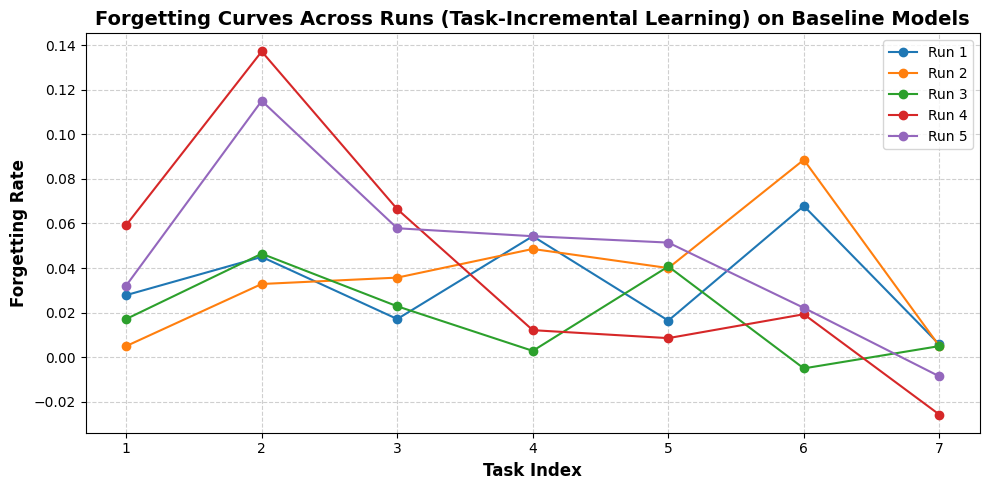

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = forgetting_rates
# Prepare data
df = pd.DataFrame([
    {"Run": d["run_id"], "Task": i + 1, "Forgetting": f}
    for d in data for i, f in enumerate(d["forgetting"])
])
avg_df = pd.DataFrame({
    "Run": [d["run_id"] for d in data],
    "Average Forgetting": [d["avg_forgetting"] for d in data]
})

# Plot forgetting per task
plt.figure(figsize=(10, 5))
for run_id, group in df.groupby("Run"):
    plt.plot(group["Task"], group["Forgetting"], marker="o", label=f"Run {run_id}")
plt.xlabel("Task Index", fontsize=12, weight='bold')
plt.ylabel("Forgetting Rate", fontsize=12, weight='bold')
plt.title("Forgetting Curves Across Runs (Task-Incremental Learning) on Baseline Models", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("fewrel_baseline_forgetting_curves.pdf", dpi=300)
plt.show()


In [29]:
# Forgetting rate for EWC
forgetting_rates, avg_forgetting_list = [], []
for run_id in range(1, 6):
    acc_path = f"/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/ewc/model_{run_id}_forgetting_matrix.json"
    accuracy_matrix = pd.read_json(acc_path)
    accuracy_matrix = make_matrices(accuracy_matrix)
    forgetting, avg_forgetting = forgetting_rate(accuracy_matrix)
    # print(accuracy_matrix)
    print(f"Run {run_id} - Forgetting: {forgetting}")
    print(f"Run {run_id} - Average Forgetting: {avg_forgetting}")
    row = {'run_id': run_id, 'forgetting': forgetting, 'avg_forgetting': avg_forgetting}
    forgetting_rates.append(row)
    avg_forgetting_list.append(avg_forgetting)
print("Average Forgetting across runs:", np.mean(avg_forgetting_list))
print("Std Average Rates across runs:", np.std(avg_forgetting_list))
write_json(forgetting_rates, f"/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/ewc/forgetting_rates.json")

Run 1 - Forgetting: [0.012142857142857011, -0.02214285714285702, 0.018571428571428017, 0.04142857142857104, 0.03642857142857103, 0.02357142857142891, 0.0050000000000000044]
Run 1 - Average Forgetting: 0.016428571428571286
Run 2 - Forgetting: [0.025714285714286023, 0.04928571428571393, 0.015714285714285015, 0.118571428571429, 0.09500000000000008, 0.07000000000000006, -0.0007142857142850012]
Run 2 - Average Forgetting: 0.05336734693877559
Run 3 - Forgetting: [0.04642857142857204, 0.08142857142857096, 0.027857142857143025, 0.029285714285715025, 0.038571428571429034, -0.004285714285714004, -0.004285714285715003]
Run 3 - Average Forgetting: 0.030714285714285867
Run 4 - Forgetting: [0.037857142857143034, 0.07142857142857106, 0.028571428571428914, 0.025000000000000022, 0.012142857142857899, -0.0050000000000000044, 0.0]
Run 4 - Average Forgetting: 0.024285714285714417
Run 5 - Forgetting: [0.04285714285714204, 0.06928571428571406, 0.04642857142857104, 0.06499999999999995, 0.06928571428571495, 0

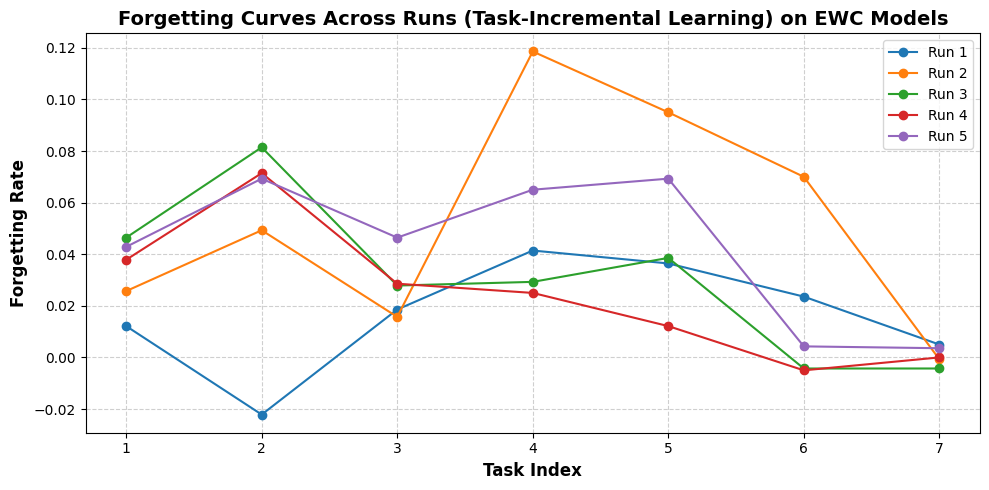

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = forgetting_rates
# Prepare data
df = pd.DataFrame([
    {"Run": d["run_id"], "Task": i + 1, "Forgetting": f}
    for d in data for i, f in enumerate(d["forgetting"])
])
avg_df = pd.DataFrame({
    "Run": [d["run_id"] for d in data],
    "Average Forgetting": [d["avg_forgetting"] for d in data]
})

# Plot forgetting per task
plt.figure(figsize=(10, 5))
for run_id, group in df.groupby("Run"):
    plt.plot(group["Task"], group["Forgetting"], marker="o", label=f"Run {run_id}")
plt.xlabel("Task Index", fontsize=12, weight='bold')
plt.ylabel("Forgetting Rate", fontsize=12, weight='bold')
plt.title("Forgetting Curves Across Runs (Task-Incremental Learning) on EWC Models", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("fewrel_ewc_forgetting_curves.pdf", dpi=300)
plt.show()


In [31]:
# Forgetting rate for MAS
forgetting_rates, avg_forgetting_list = [], []
for run_id in range(1, 6):
    acc_path = f"/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/mas/model_{run_id}_forgetting_matrix.json"
    accuracy_matrix = pd.read_json(acc_path)
    accuracy_matrix = make_matrices(accuracy_matrix)
    forgetting, avg_forgetting = forgetting_rate(accuracy_matrix)
    # print(accuracy_matrix)
    print(f"Run {run_id} - Forgetting: {forgetting}")
    print(f"Run {run_id} - Average Forgetting: {avg_forgetting}")
    row = {'run_id': run_id, 'forgetting': forgetting, 'avg_forgetting': avg_forgetting}
    forgetting_rates.append(row)
    avg_forgetting_list.append(avg_forgetting)
print("Average Forgetting across runs:", np.mean(avg_forgetting_list))
print("Std Average Rates across runs:", np.std(avg_forgetting_list))
write_json(forgetting_rates, f"/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/mas/forgetting_rates.json")

Run 1 - Forgetting: [0.018571428571429016, 0.024285714285714022, 0.0007142857142851122, 0.06571428571428606, 0.04285714285714304, 0.018571428571428905, 0.0014285714285720008]
Run 1 - Average Forgetting: 0.024591836734694023
Run 2 - Forgetting: [0.025714285714286023, 0.04928571428571393, 0.015714285714285015, 0.118571428571429, 0.09500000000000008, 0.07000000000000006, -0.0007142857142850012]
Run 2 - Average Forgetting: 0.05336734693877559
Run 3 - Forgetting: [0.04642857142857204, 0.08142857142857096, 0.027857142857143025, 0.029285714285715025, 0.038571428571429034, -0.004285714285714004, -0.004285714285715003]
Run 3 - Average Forgetting: 0.030714285714285867
Run 4 - Forgetting: [0.037857142857143034, 0.07142857142857106, 0.028571428571428914, 0.025000000000000022, 0.012142857142857899, -0.0050000000000000044, 0.0]
Run 4 - Average Forgetting: 0.024285714285714417
Run 5 - Forgetting: [0.04285714285714204, 0.06928571428571406, 0.04642857142857104, 0.06499999999999995, 0.06928571428571495,

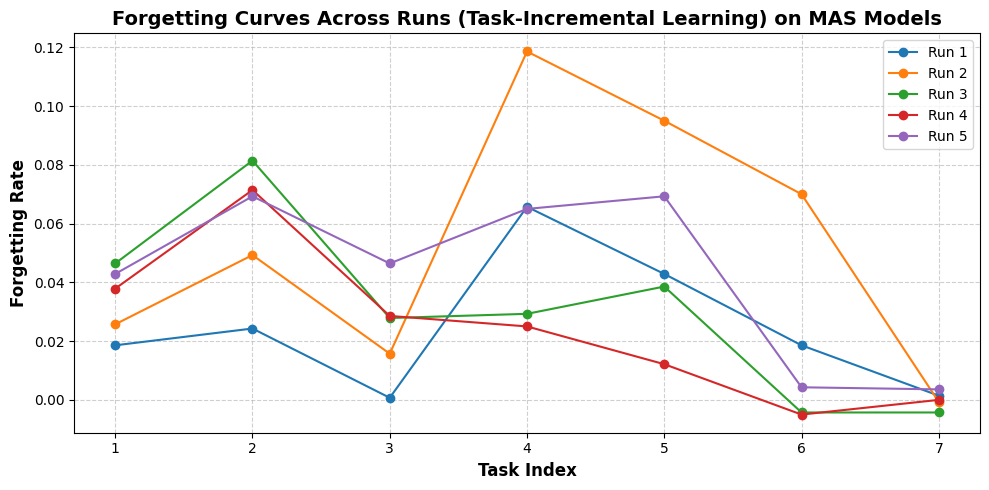

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = forgetting_rates
# Prepare data
df = pd.DataFrame([
    {"Run": d["run_id"], "Task": i + 1, "Forgetting": f}
    for d in data for i, f in enumerate(d["forgetting"])
])
avg_df = pd.DataFrame({
    "Run": [d["run_id"] for d in data],
    "Average Forgetting": [d["avg_forgetting"] for d in data]
})

# Plot forgetting per task
plt.figure(figsize=(10, 5))
for run_id, group in df.groupby("Run"):
    plt.plot(group["Task"], group["Forgetting"], marker="o", label=f"Run {run_id}")
plt.xlabel("Task Index", fontsize=12, weight='bold')
plt.ylabel("Forgetting Rate", fontsize=12, weight='bold')
plt.title("Forgetting Curves Across Runs (Task-Incremental Learning) on MAS Models", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("fewrel_mas_forgetting_curves.pdf", dpi=300)
plt.show()


In [33]:
# Forgetting rate for SI
forgetting_rates, avg_forgetting_list = [], []
for run_id in range(1, 6):
    acc_path = f"/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/si/model_{run_id}_forgetting_matrix.json"
    accuracy_matrix = pd.read_json(acc_path)
    accuracy_matrix = make_matrices(accuracy_matrix)
    forgetting, avg_forgetting = forgetting_rate(accuracy_matrix)
    # print(accuracy_matrix)
    print(f"Run {run_id} - Forgetting: {forgetting}")
    print(f"Run {run_id} - Average Forgetting: {avg_forgetting}")
    row = {'run_id': run_id, 'forgetting': forgetting, 'avg_forgetting': avg_forgetting}
    forgetting_rates.append(row)
    avg_forgetting_list.append(avg_forgetting)
print("Average Forgetting across runs:", np.mean(avg_forgetting_list))
print("Std Average Rates across runs:", np.std(avg_forgetting_list))
write_json(forgetting_rates, f"/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/si/forgetting_rates.json")

Run 1 - Forgetting: [0.017142857142857015, 0.04642857142857104, 0.03857142857142892, 0.05500000000000005, 0.04642857142857104, 0.02357142857142902, 0.002142857142857002]
Run 1 - Average Forgetting: 0.032755102040816296
Run 2 - Forgetting: [0.0050000000000000044, 0.03285714285714303, 0.03571428571428503, 0.04857142857142793, 0.040000000000000036, 0.08857142857142908, 0.0050000000000000044]
Run 2 - Average Forgetting: 0.03653061224489788
Run 3 - Forgetting: [0.017142857142857015, 0.04642857142857104, 0.02285714285714302, 0.0028571428571430024, 0.040714285714285925, -0.0050000000000000044, 0.0050000000000000044]
Run 3 - Average Forgetting: 0.018571428571428572
Run 4 - Forgetting: [0.05928571428571405, 0.137142857142857, 0.06642857142857095, 0.012142857142857011, 0.008571428571428119, 0.019285714285714017, -0.025714285714286023]
Run 4 - Average Forgetting: 0.03959183673469359
Run 5 - Forgetting: [0.03214285714285703, 0.1150000000000001, 0.05785714285714305, 0.05428571428571394, 0.051428571

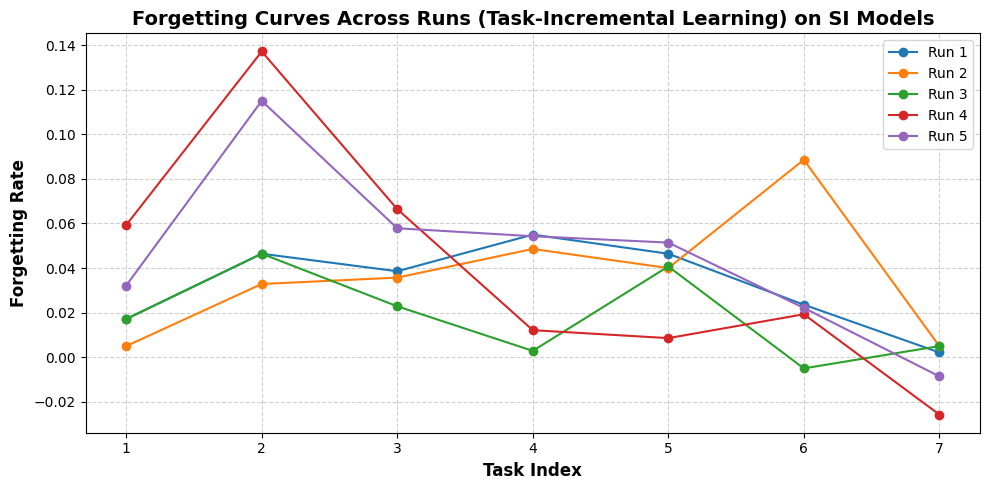

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = forgetting_rates
# Prepare data
df = pd.DataFrame([
    {"Run": d["run_id"], "Task": i + 1, "Forgetting": f}
    for d in data for i, f in enumerate(d["forgetting"])
])
avg_df = pd.DataFrame({
    "Run": [d["run_id"] for d in data],
    "Average Forgetting": [d["avg_forgetting"] for d in data]
})

# Plot forgetting per task
plt.figure(figsize=(10, 5))
for run_id, group in df.groupby("Run"):
    plt.plot(group["Task"], group["Forgetting"], marker="o", label=f"Run {run_id}")
plt.xlabel("Task Index", fontsize=12, weight='bold')
plt.ylabel("Forgetting Rate", fontsize=12, weight='bold')
plt.title("Forgetting Curves Across Runs (Task-Incremental Learning) on SI Models", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("fewrel_si_forgetting_curves.pdf", dpi=300)
plt.show()
